**Question 1:** What is the fundamental idea behind ensemble techniques? How does bagging differ from boosting in terms of approach and objective?

**Answer 1:**

The fundamental idea behind ensemble techniques is to combine multiple weak or base learners to form a more accurate, stable, and robust model than any single learner.

**1. Bagging (Bootstrap Aggregating):**

Builds multiple models independently on different random subsets of data (bootstrapped samples).

Combines results (e.g., by voting or averaging).

Objective: Reduce variance and avoid overfitting.

Example: Random Forest.

**2. Boosting:**

Builds models sequentially, where each new model focuses on the errors of the previous ones.

Objective: Reduce bias by correcting mistakes of earlier learners.

Example: AdaBoost, Gradient Boosting.

**Question 2: Explain how the Random Forest Classifier reduces overfitting compared to a single decision tree. Mention the role of two key hyperparameters in this process.**

**Answer 2:**

A single decision tree tends to overfit because it captures noise and specific details of the training data.
Random Forest reduces overfitting by:

**Bagging (bootstrap sampling):** Each tree is trained on a random subset of data.

Feature randomness: Each split considers a random subset of features → less correlation between trees.
The final prediction is based on the average/vote of all trees, reducing variance.

Two key hyperparameters:

**n_estimators:** Number of trees. More trees → lower variance, better generalization.

**max_features:** Number of features considered per split. Lower value → more diversity → less overfitting.


**Question 3: What is Stacking in ensemble learning? How does it differ from traditional bagging/boosting methods? Provide a simple example use case.**

**Answer 3:**

Stacking (Stacked Generalization) combines multiple models (called base learners) and uses a meta-model to learn how to best combine their predictions.

Difference:

Bagging: Combines independent models via averaging/voting.

Boosting: Sequentially builds models to correct errors.

Stacking: Uses a meta-learner trained on predictions from base models to learn optimal combination weights.

Example Use Case:
Use Logistic Regression, Random Forest, and XGBoost as base learners; train a Logistic Regression as a meta-learner on their predictions to improve overall accuracy.



**Question 4:What is the OOB Score in Random Forest, and why is it useful? How does it help in model evaluation without a separate validation set?**

**Answer 4:**

OOB (Out-of-Bag) Score is the accuracy computed using data not included in the bootstrap sample for each tree.

Each tree in the forest trains on a random subset (~63% of the data).

The remaining ~37% (OOB samples) act as unseen data.

The model predicts on OOB samples, and these predictions estimate generalization performance.

Usefulness:

Provides an internal cross-validation method.

Avoids needing a separate validation set → saves data.

Offers an unbiased estimate of model performance.




**Question 5:** Compare AdaBoost and Gradient Boosting in terms of:
● How they handle errors from weak learners
● Weight adjustment mechanism
● Typical use cases

**Answer 5:**

| **Aspect**            | **AdaBoost**                                                      | **Gradient Boosting**                                                       |
| --------------------- | ----------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **Error Handling**    | Focuses more on misclassified samples by adjusting their weights. | Fits new learners to residuals (errors) of the previous model.              |
| **Weight Adjustment** | Increases weight of misclassified samples exponentially.          | Learners correct prediction errors using gradient descent on loss function. |
| **Typical Use Cases** | When data is small, simple, and less noisy.                       | When high predictive accuracy is needed; supports custom loss functions.    |



**Question 6:Why does CatBoost perform well on categorical features without requiring extensive preprocessing? Briefly explain its handling of categorical variables.**

**Answer 6:**

CatBoost handles categorical features natively using ordered target encoding and statistical methods that prevent target leakage.

Converts categories into numerical values using the mean target value calculated in an order-sensitive way.

Avoids one-hot encoding and high-dimensional feature expansion.

Efficiently combines categorical features and applies built-in regularization.
Thus, it performs well without extensive preprocessing.


In [1]:
"""
**Question 7: KNN Classifier Assignment: Wine Dataset Analysis with Optimization**

**Task:**
1. Load the Wine dataset (sklearn.datasets.load_wine()).
2. Split data into 70% train and 30% test.
3. Train a KNN classifier (default K=5) without scaling and evaluate using:
a. Accuracy
b. Precision, Recall, F1-Score (print classification report)
4. Apply StandardScaler, retrain KNN, and compare metrics.
5. Use GridSearchCV to find the best K (test K=1 to 20) and distance metric
(Euclidean, Manhattan).
6. Train the optimized KNN and compare results with the unscaled/scaled versions.
"""

# Answer 7:

# Question 7: KNN Classifier - Wine Dataset

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load data
data = load_wine()
X, y = data.data, data.target

# 2. Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Train KNN without scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

print("Unscaled K=5 Accuracy:", accuracy_score(y_test, y_pred_unscaled))
print(classification_report(y_test, y_pred_unscaled))

# 4. Apply StandardScaler and retrain
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)

print("\nScaled K=5 Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

# 5. GridSearchCV for best K (1–20) and metric
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid.best_params_)

# 6. Train optimized KNN
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)

print("\nOptimized KNN Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Unscaled K=5 Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        18
           1       0.78      0.67      0.72        21
           2       0.50      0.60      0.55        15

    accuracy                           0.72        54
   macro avg       0.72      0.72      0.72        54
weighted avg       0.74      0.72      0.73        54


Scaled K=5 Accuracy: 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.86      0.92        21
           2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54


Best Parameters: {'metric': 'euclidean', 'n_neighbors': 11}

Optimized KNN Accuracy: 0.9629629629629629
              precision    recall  f1-score   supp

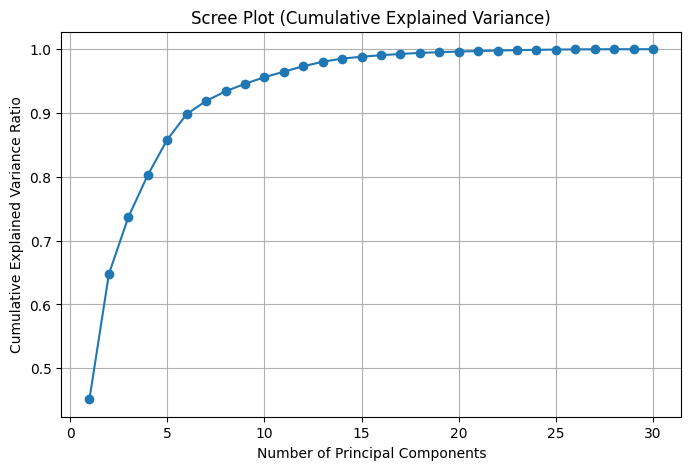

Number of components to retain 95% variance: 10
Accuracy (Original data): 0.9591
Accuracy (PCA-transformed, 95% variance): 0.9532


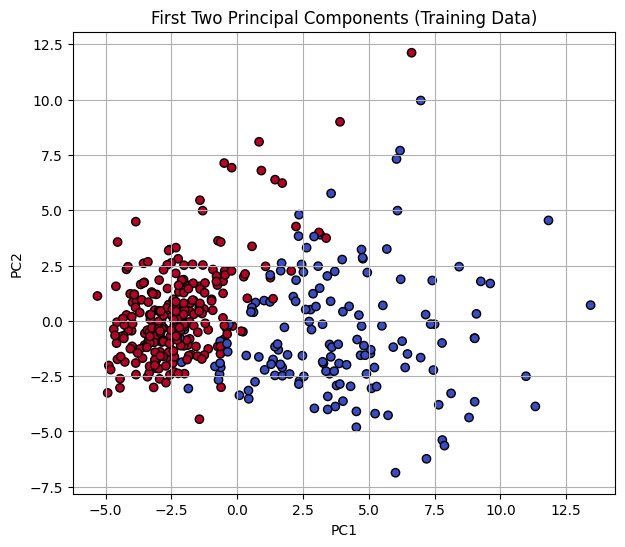

In [3]:
'''
Question 8 : PCA + KNN with Variance Analysis and Visualization
Task:
1. Load the Breast Cancer dataset (sklearn.datasets.load_breast_cancer()).
2. Apply PCA and plot the scree plot (explained variance ratio).
3. Retain 95% variance and transform the dataset.
4. Train KNN on the original data and PCA-transformed data, then compare
accuracy.
5. Visualize the first two principal components using a scatter plot (color by class).
'''

#Answer 8:

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Load Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features (important for PCA & KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Apply PCA and plot scree plot (explained variance ratio)
pca = PCA()
pca.fit(X_train_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot (Cumulative Explained Variance)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid(True)
plt.show()

# 3. Retain 95% variance and transform dataset
pca_95 = PCA(0.95)  # keep components explaining 95% variance
X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

print(f"Number of components to retain 95% variance: {pca_95.n_components_}")

# 4. Train KNN on original and PCA-transformed data
knn = KNeighborsClassifier(n_neighbors=5)

# On original data
knn.fit(X_train_scaled, y_train)
y_pred_orig = knn.predict(X_test_scaled)
acc_orig = accuracy_score(y_test, y_pred_orig)

# On PCA-transformed data
knn.fit(X_train_pca, y_train)
y_pred_pca = knn.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Accuracy (Original data): {acc_orig:.4f}")
print(f"Accuracy (PCA-transformed, 95% variance): {acc_pca:.4f}")

# 5. Visualize first two principal components
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_train_scaled)

plt.figure(figsize=(7,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("First Two Principal Components (Training Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


MSE (Euclidean, K=5): 4837.0363
MSE (Manhattan, K=5): 5428.5875


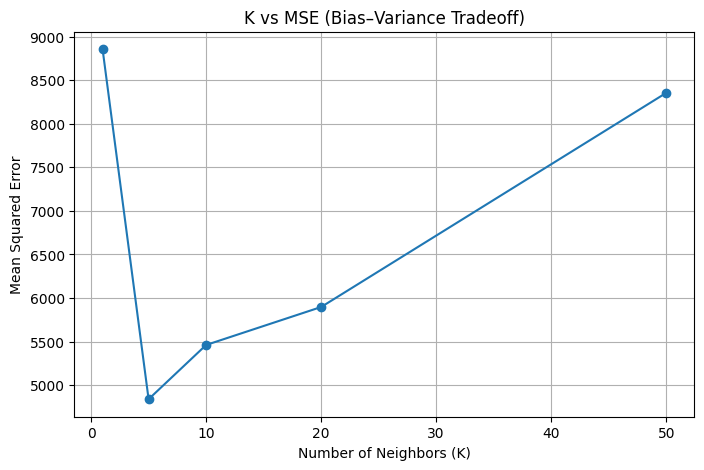

In [4]:
'''
Question 9:KNN Regressor with Distance Metrics and K-Value
Analysis
Task:
1. Generate a synthetic regression dataset
(sklearn.datasets.make_regression(n_samples=500, n_features=10)).
2. Train a KNN regressor with:
a. Euclidean distance (K=5)
b. Manhattan distance (K=5)
c. Compare Mean Squared Error (MSE) for both.
3. Test K=1, 5, 10, 20, 50 and plot K vs. MSE to analyze bias-variance tradeoff.
'''

# Answer 9:

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Generate synthetic regression dataset
X, y = make_regression(n_samples=500, n_features=10, noise=10, random_state=42)

# Split into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (important for distance-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2a. KNN Regressor with Euclidean distance (default metric)
knn_euclidean = KNeighborsRegressor(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train_scaled, y_train)
y_pred_euclidean = knn_euclidean.predict(X_test_scaled)
mse_euclidean = mean_squared_error(y_test, y_pred_euclidean)

# 2b. KNN Regressor with Manhattan distance
knn_manhattan = KNeighborsRegressor(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
mse_manhattan = mean_squared_error(y_test, y_pred_manhattan)

print(f"MSE (Euclidean, K=5): {mse_euclidean:.4f}")
print(f"MSE (Manhattan, K=5): {mse_manhattan:.4f}")

# 3. Analyze Bias-Variance Tradeoff: K vs MSE
K_values = [1, 5, 10, 20, 50]
mse_values = []

for k in K_values:
    knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)

# Plot K vs MSE
plt.figure(figsize=(8,5))
plt.plot(K_values, mse_values, marker='o')
plt.title("K vs MSE (Bias–Variance Tradeoff)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()


Missing values before imputation:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Algorithm: brute
Accuracy: 0.7359
Training Time: 0.0041 seconds
              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81       150
         1.0       0.65      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.71      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231


Algorithm: kd_tree
Accuracy: 0.7359
Training Time: 0.0087 seconds
              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81       150
         1.0       0.65      0.53      0.59        81

    accuracy                           0.7

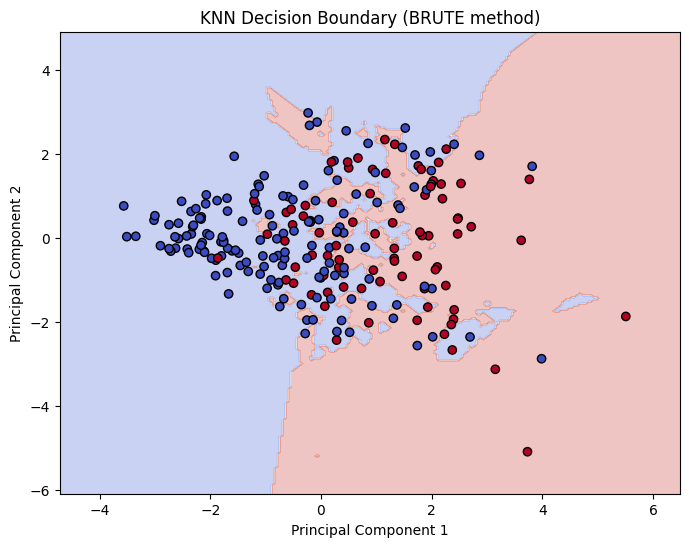

In [5]:
'''
Question 10: KNN with KD-Tree/Ball Tree, Imputation, and Real-World
Data
Task:
1. Load the Pima Indians Diabetes dataset (contains missing values).
2. Use KNN Imputation (sklearn.impute.KNNImputer) to fill missing values.
3. Train KNN using:
a. Brute-force method
b. KD-Tree
c. Ball Tree
4. Compare their training time and accuracy.
5. Plot the decision boundary for the best-performing method (use 2 most important
features).
'''

# Answer 10:

# Question 10: KNN with KD-Tree/Ball Tree, Imputation, and Real-World Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

# 1. Load the Pima Indians Diabetes dataset
# Dataset URL: https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

data = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv",
    names=columns
)

# Display missing value statistics (0 values indicate missing measurements)
print("Missing values before imputation:")
print((data == 0).sum())

# Replace invalid zeros with NaN in selected features
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[cols_with_zero] = data[cols_with_zero].replace(0, np.nan)

# 2. Use KNN Imputer to fill missing values
imputer = KNNImputer(n_neighbors=5)
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# Split into features and target
X = data_imputed.drop("Outcome", axis=1)
y = data_imputed["Outcome"]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 3. Train KNN using three algorithms
algorithms = ['brute', 'kd_tree', 'ball_tree']
results = {}

for algo in algorithms:
    start = time.time()
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    end = time.time()

    acc = accuracy_score(y_test, y_pred)
    results[algo] = {'Accuracy': acc, 'Time': end - start}
    print(f"\nAlgorithm: {algo}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Training Time: {end - start:.4f} seconds")
    print(classification_report(y_test, y_pred))

# 4. Compare accuracy and time
results_df = pd.DataFrame(results).T
print("\n=== Comparison of KNN Implementations ===")
print(results_df)

# 5. Decision boundary visualization (using top 2 features via PCA)
best_algo = results_df['Accuracy'].idxmax()
print(f"\nBest performing algorithm: {best_algo}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

# Train best model on PCA data
knn_best = KNeighborsClassifier(n_neighbors=5, algorithm=best_algo)
knn_best.fit(X_train_pca, y_train_pca)

# Decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = knn_best.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title(f"KNN Decision Boundary ({best_algo.upper()} method)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()
